In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [3]:
DATA_DIR = Path(".")

files = list(DATA_DIR.glob("*viirs*.csv"))

files

[WindowsPath('viirs-jpss1_2023_India.csv'),
 WindowsPath('viirs-jpss1_2024_India.csv'),
 WindowsPath('viirs-snpp_2023_India.csv'),
 WindowsPath('viirs-snpp_2024_India.csv')]

In [4]:
df_2023 = pd.read_csv("viirs-snpp_2023_India.csv")
df_2024 = pd.read_csv("viirs-snpp_2024_India.csv")

print("2023 shape:", df_2023.shape)
print("2024 shape:", df_2024.shape)

2023 shape: (579733, 15)
2024 shape: (552312, 15)


In [5]:
df_2023["year"] = 2023
df_2024["year"] = 2024

In [6]:
print("2023")
display(df_2023.head())

print("\n2024")
display(df_2024.head())

2023


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,year
0,11.530,77.198,338.670,0.460,0.470,2023-01-01,745,N,VIIRS,n,2,299.780,2.970,D,0,2023
1,12.094,76.537,338.620,0.500,0.490,2023-01-01,745,N,VIIRS,n,2,300.680,3.510,D,0,2023
2,9.359,77.924,341.930,0.450,0.470,2023-01-01,745,N,VIIRS,n,2,304.720,3.120,D,0,2023
3,9.836,77.898,332.280,0.440,0.460,2023-01-01,745,N,VIIRS,n,2,301.620,2.120,D,0,2023
4,10.127,78.576,334.130,0.400,0.440,2023-01-01,745,N,VIIRS,n,2,301.730,3.630,D,0,2023



2024


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,year
0,17.170,79.990,332.050,0.630,0.720,2024-01-01,702,N,VIIRS,n,2,294.540,3.680,D,0,2024
1,18.243,83.956,333.710,0.330,0.560,2024-01-01,702,N,VIIRS,n,2,296.660,1.750,D,0,2024
2,18.741,83.980,340.180,0.320,0.550,2024-01-01,702,N,VIIRS,n,2,299.860,4.240,D,0,2024
3,18.709,83.453,327.850,0.350,0.570,2024-01-01,702,N,VIIRS,n,2,299.340,2.870,D,0,2024
4,18.709,83.450,329.700,0.350,0.570,2024-01-01,702,N,VIIRS,n,2,296.810,2.040,D,0,2024


In [7]:
print("2023 columns:")
print(df_2023.columns.tolist())

print("\n2024 columns:")
print(df_2024.columns.tolist())

2023 columns:
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type', 'year']

2024 columns:
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type', 'year']


In [8]:
df = pd.concat(
    [df_2023, df_2024],
    ignore_index=True
)

print("Combined shape:", df.shape)
display(df.head())

Combined shape: (1132045, 16)


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,year
0,11.530,77.198,338.670,0.460,0.470,2023-01-01,745,N,VIIRS,n,2,299.780,2.970,D,0,2023
1,12.094,76.537,338.620,0.500,0.490,2023-01-01,745,N,VIIRS,n,2,300.680,3.510,D,0,2023
2,9.359,77.924,341.930,0.450,0.470,2023-01-01,745,N,VIIRS,n,2,304.720,3.120,D,0,2023
3,9.836,77.898,332.280,0.440,0.460,2023-01-01,745,N,VIIRS,n,2,301.620,2.120,D,0,2023
4,10.127,78.576,334.130,0.400,0.440,2023-01-01,745,N,VIIRS,n,2,301.730,3.630,D,0,2023


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1132045 entries, 0 to 1132044
Data columns (total 16 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   latitude    1132045 non-null  float64
 1   longitude   1132045 non-null  float64
 2   bright_ti4  1132045 non-null  float64
 3   scan        1132045 non-null  float64
 4   track       1132045 non-null  float64
 5   acq_date    1132045 non-null  object 
 6   acq_time    1132045 non-null  int64  
 7   satellite   1132045 non-null  object 
 8   instrument  1132045 non-null  object 
 9   confidence  1132045 non-null  object 
 10  version     1132045 non-null  int64  
 11  bright_ti5  1132045 non-null  float64
 12  frp         1132045 non-null  float64
 13  daynight    1132045 non-null  object 
 14  type        1132045 non-null  int64  
 15  year        1132045 non-null  int64  
dtypes: float64(7), int64(4), object(5)
memory usage: 138.2+ MB


In [10]:
df.dtypes

latitude      float64
longitude     float64
bright_ti4    float64
scan          float64
track         float64
acq_date       object
acq_time        int64
satellite      object
instrument     object
confidence     object
version         int64
bright_ti5    float64
frp           float64
daynight       object
type            int64
year            int64
dtype: object

In [11]:
df["acq_date"] = pd.to_datetime(df["acq_date"], errors="coerce")

df["acq_date"].min(), df["acq_date"].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2024-12-31 00:00:00'))

In [12]:
missing = (
    df.isna()
      .sum()
      .to_frame("missing_count")
)

missing["missing_percent"] = (
    missing["missing_count"] / len(df) * 100
)

missing.sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
latitude,0,0.000
longitude,0,0.000
bright_ti4,0,0.000
scan,0,0.000
track,0,0.000
acq_date,0,0.000
acq_time,0,0.000
satellite,0,0.000
instrument,0,0.000
confidence,0,0.000


In [13]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


In [14]:
print(
    "Duplicate latitude/longitude:",
    df.duplicated(subset=["latitude", "longitude"]).sum()
)

Duplicate latitude/longitude: 175


In [15]:
print("Latitude range:")
print(df["latitude"].min(), "to", df["latitude"].max())

print("\nLongitude range:")
print(df["longitude"].min(), "to", df["longitude"].max())

Latitude range:
8.04682 to 35.11223

Longitude range:
68.50764 to 97.21292


In [16]:
print(
    "Rows outside plausible India bounding region:",
    (
        (df["latitude"] < 6) |
        (df["latitude"] > 38) |
        (df["longitude"] < 68) |
        (df["longitude"] > 98)
    ).sum()
)

Rows outside plausible India bounding region: 0


In [17]:
categorical_cols = [
    "satellite",
    "instrument",
    "confidence",
    "version",
    "daynight",
    "type"
]

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== satellite =====
satellite
N    1132045
Name: count, dtype: int64

===== instrument =====
instrument
VIIRS    1132045
Name: count, dtype: int64

===== confidence =====
confidence
n    902228
l    202189
h     27628
Name: count, dtype: int64

===== version =====
version
2    1132045
Name: count, dtype: int64

===== daynight =====
daynight
D    808386
N    323659
Name: count, dtype: int64

===== type =====
type
0    988807
2    140951
3      2271
1        16
Name: count, dtype: int64


In [18]:
daynight_counts = df["daynight"].value_counts()

display(daynight_counts)

daynight_percent = (
    df["daynight"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

display(daynight_percent)

daynight
D    808386
N    323659
Name: count, dtype: int64

daynight
D   71.410
N   28.590
Name: proportion, dtype: float64

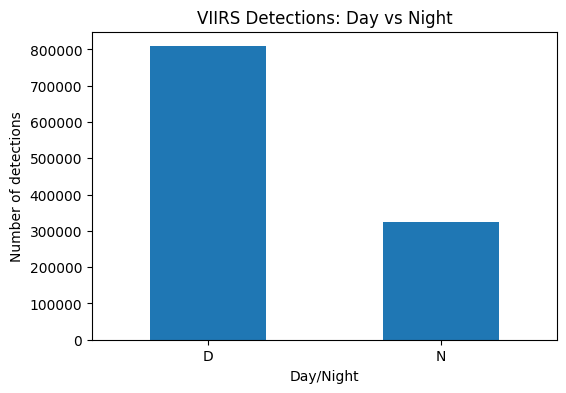

In [19]:
daynight_counts.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("VIIRS Detections: Day vs Night")
plt.xlabel("Day/Night")
plt.ylabel("Number of detections")
plt.xticks(rotation=0)
plt.show()

In [20]:
viirs_night = df[
    df["daynight"].astype(str).str.upper() == "N"
].copy()

print("All VIIRS detections :", len(df))
print("Nighttime detections :", len(viirs_night))
print(
    "Nighttime percentage :",
    round(len(viirs_night) / len(df) * 100, 2),
    "%"
)

All VIIRS detections : 1132045
Nighttime detections : 323659
Nighttime percentage : 28.59 %


In [21]:
viirs_night["year"] = viirs_night["acq_date"].dt.year

year_counts = viirs_night["year"].value_counts().sort_index()

display(year_counts)

year
2023    166934
2024    156725
Name: count, dtype: int64

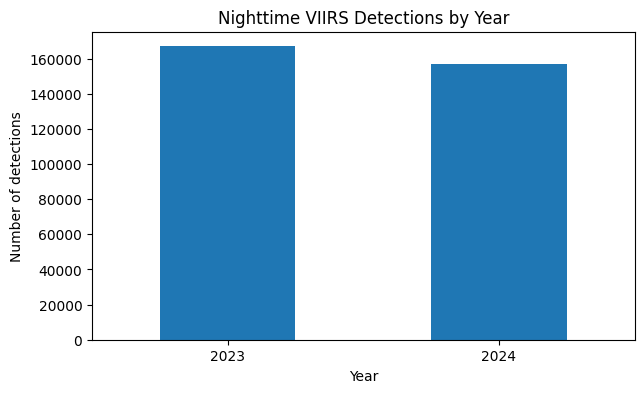

In [22]:
year_counts.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Nighttime VIIRS Detections by Year")
plt.xlabel("Year")
plt.ylabel("Number of detections")
plt.xticks(rotation=0)
plt.show()

In [23]:
daily_counts = (
    viirs_night
    .groupby("acq_date")
    .size()
)

display(daily_counts.describe())

count    707.000
mean     457.792
std      547.916
min        1.000
25%      140.000
50%      329.000
75%      517.000
max     4698.000
dtype: float64

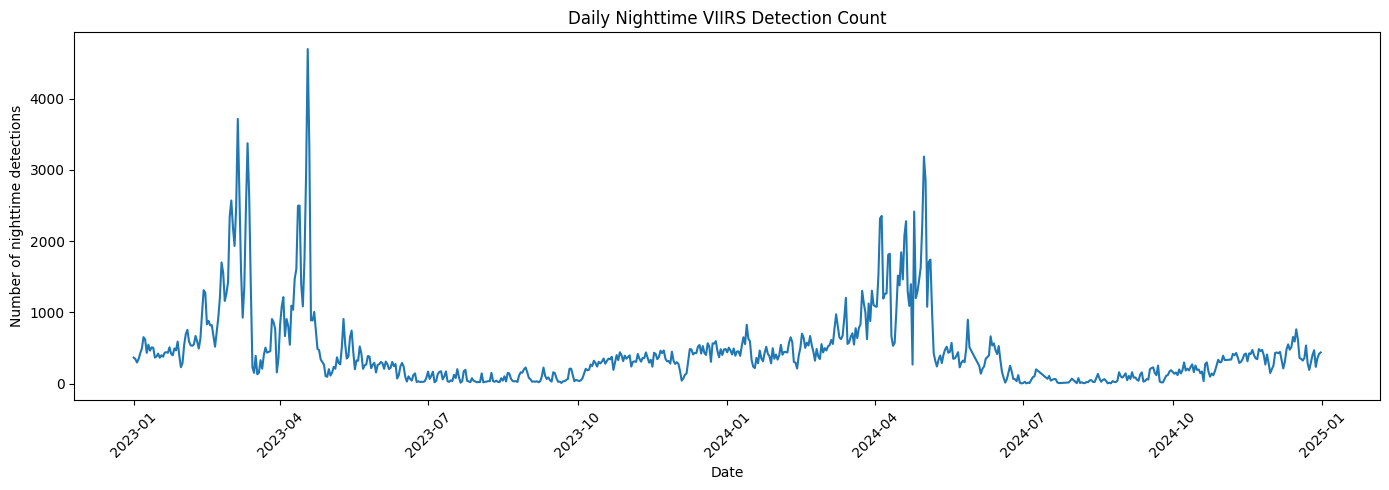

In [24]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_counts.index,
    daily_counts.values
)

plt.title("Daily Nighttime VIIRS Detection Count")
plt.xlabel("Date")
plt.ylabel("Number of nighttime detections")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
monthly_counts = (
    viirs_night
    .groupby(viirs_night["acq_date"].dt.to_period("M"))
    .size()
)

display(monthly_counts)

acq_date
2023-01    13372
2023-02    24653
2023-03    38469
2023-04    36966
2023-05    10858
2023-06     4673
2023-07     2615
2023-08     2340
2023-09     2192
2023-10     8297
2023-11    10221
2023-12    12278
2024-01    13609
2024-02    13628
2024-03    24344
2024-04    43305
2024-05    20985
2024-06     6624
2024-07     1029
2024-08     1223
2024-09     3154
2024-10     6077
2024-11    10070
2024-12    12677
Freq: M, dtype: int64

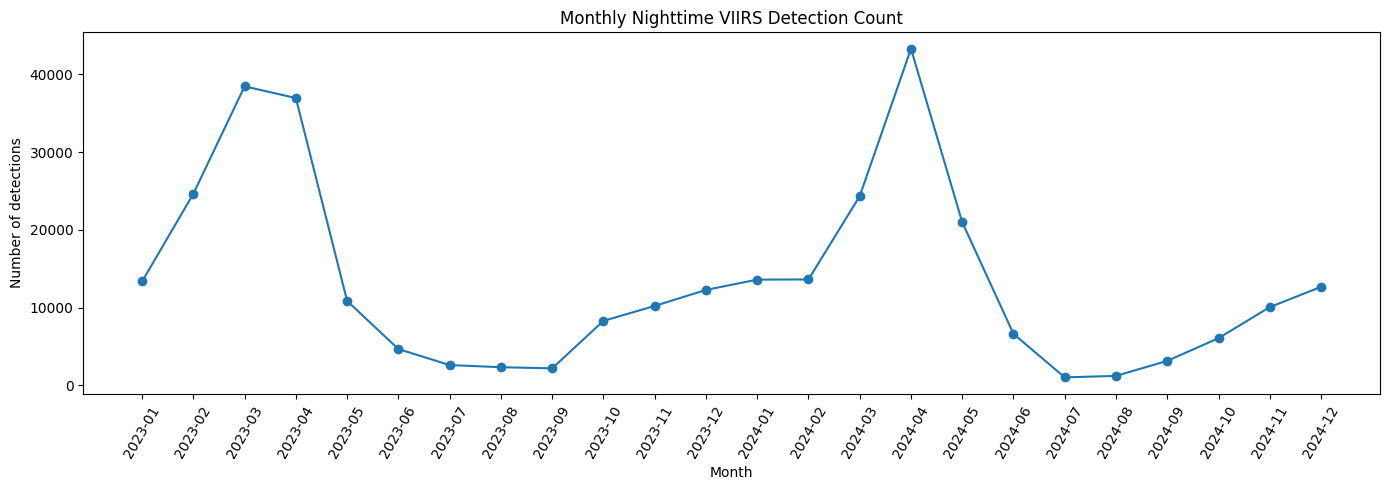

In [26]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_counts.index.astype(str),
    monthly_counts.values,
    marker="o"
)

plt.title("Monthly Nighttime VIIRS Detection Count")
plt.xlabel("Month")
plt.ylabel("Number of detections")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [27]:
thermal_cols = [
    "bright_ti4",
    "bright_ti5",
    "frp"
]

viirs_night[thermal_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
bright_ti4,323659.000,308.831,8.895,295.000,303.050,307.040,312.240,367.000
bright_ti5,323659.000,290.529,6.578,150.000,288.110,291.210,293.880,423.340
frp,323659.000,1.720,3.137,0.000,0.900,1.370,2.080,1552.820


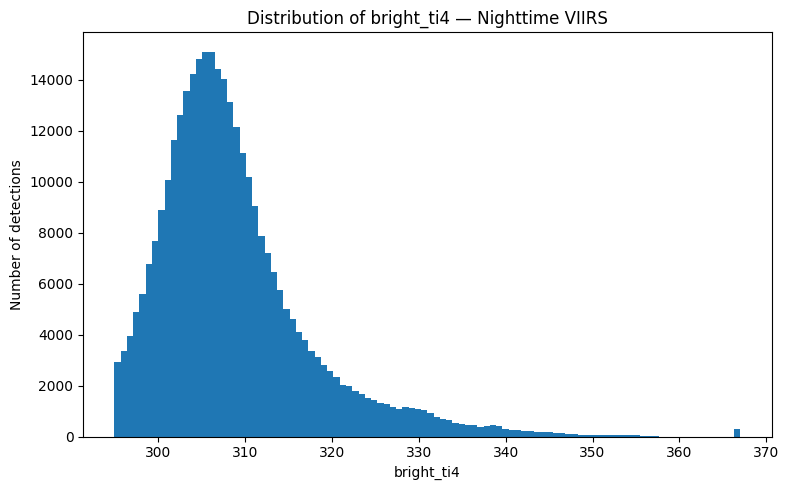

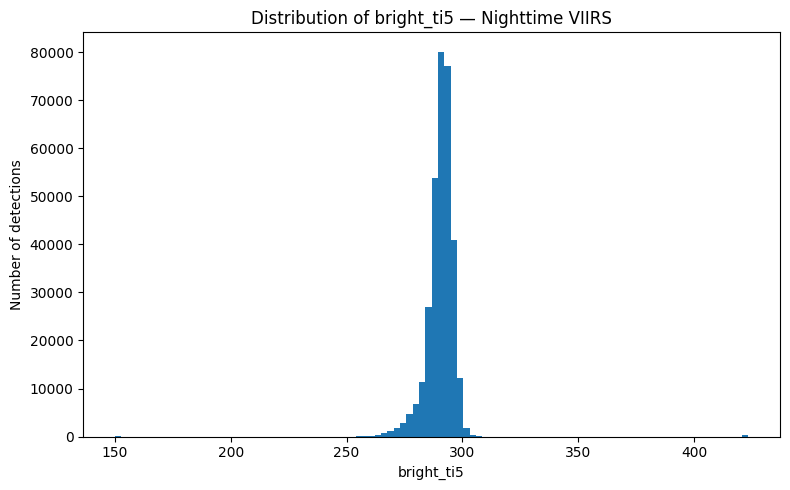

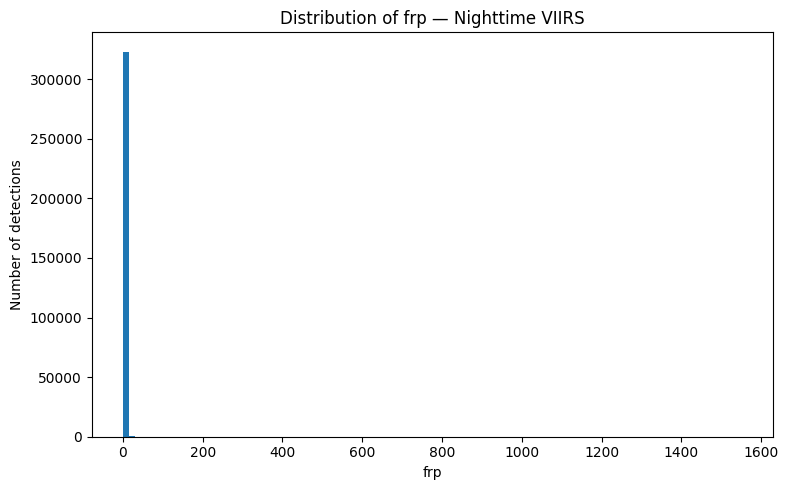

In [28]:
for col in thermal_cols:

    plt.figure(figsize=(8, 5))

    plt.hist(
        viirs_night[col].dropna(),
        bins=100
    )

    plt.title(f"Distribution of {col} — Nighttime VIIRS")
    plt.xlabel(col)
    plt.ylabel("Number of detections")

    plt.tight_layout()
    plt.show()

In [29]:
display(
    viirs_night[
        ["bright_ti4", "bright_ti5", "frp"]
    ].corr()
)

,bright_ti4,bright_ti5,frp
bright_ti4,1.000,0.348,0.292
bright_ti5,0.348,1.000,0.093
frp,0.292,0.093,1.000


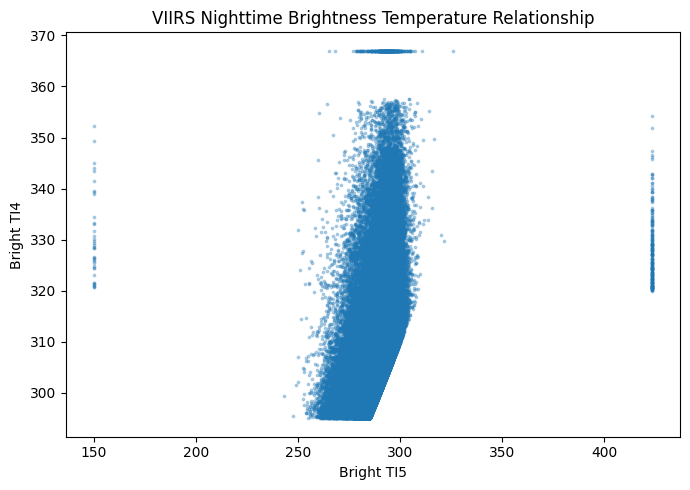

In [30]:
plt.figure(figsize=(7, 5))

plt.scatter(
    viirs_night["bright_ti5"],
    viirs_night["bright_ti4"],
    s=3,
    alpha=0.3
)

plt.xlabel("Bright TI5")
plt.ylabel("Bright TI4")
plt.title("VIIRS Nighttime Brightness Temperature Relationship")

plt.tight_layout()
plt.show()

In [31]:
confidence_counts = (
    viirs_night["confidence"]
    .value_counts(dropna=False)
    .sort_index()
)

display(confidence_counts)

confidence
h       316
n    323343
Name: count, dtype: int64

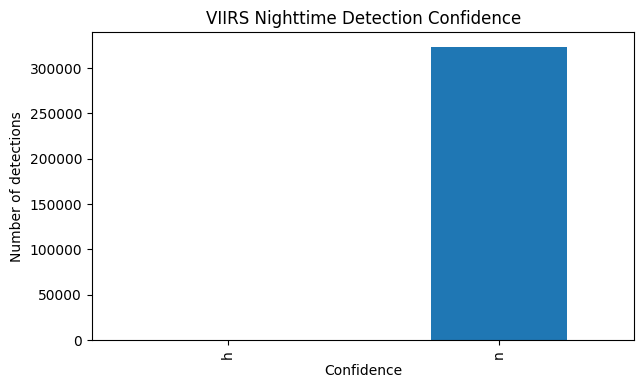

In [32]:
confidence_counts.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("VIIRS Nighttime Detection Confidence")
plt.xlabel("Confidence")
plt.ylabel("Number of detections")
plt.show()

In [33]:
display(
    viirs_night.groupby("confidence")["frp"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
confidence,,,,,,,,
h,316.000,15.804,87.085,3.010,5.725,8.675,12.920,1552.820
n,323343.000,1.706,1.506,0.000,0.900,1.370,2.080,90.540


In [34]:
display(
    viirs_night.groupby("confidence")["bright_ti4"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
confidence,,,,,,,,
h,316.000,367.000,0.000,367.000,367.000,367.000,367.000,367.000
n,323343.000,308.774,8.712,295.000,303.050,307.030,312.210,357.570


In [35]:
type_counts = (
    viirs_night["type"]
    .value_counts(dropna=False)
    .sort_index()
)

display(type_counts)

type
0    196305
1        16
2    125402
3      1936
Name: count, dtype: int64

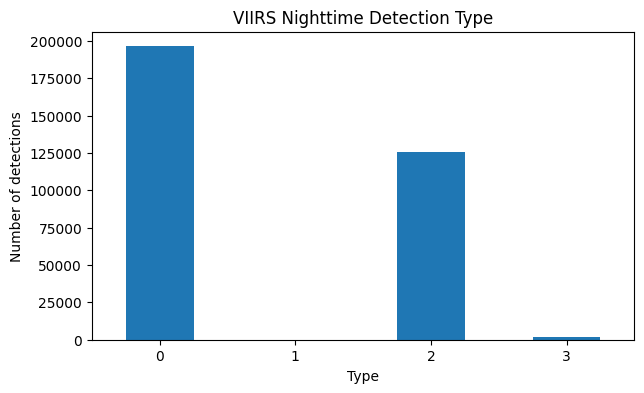

In [36]:
type_counts.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("VIIRS Nighttime Detection Type")
plt.xlabel("Type")
plt.ylabel("Number of detections")
plt.xticks(rotation=0)
plt.show()

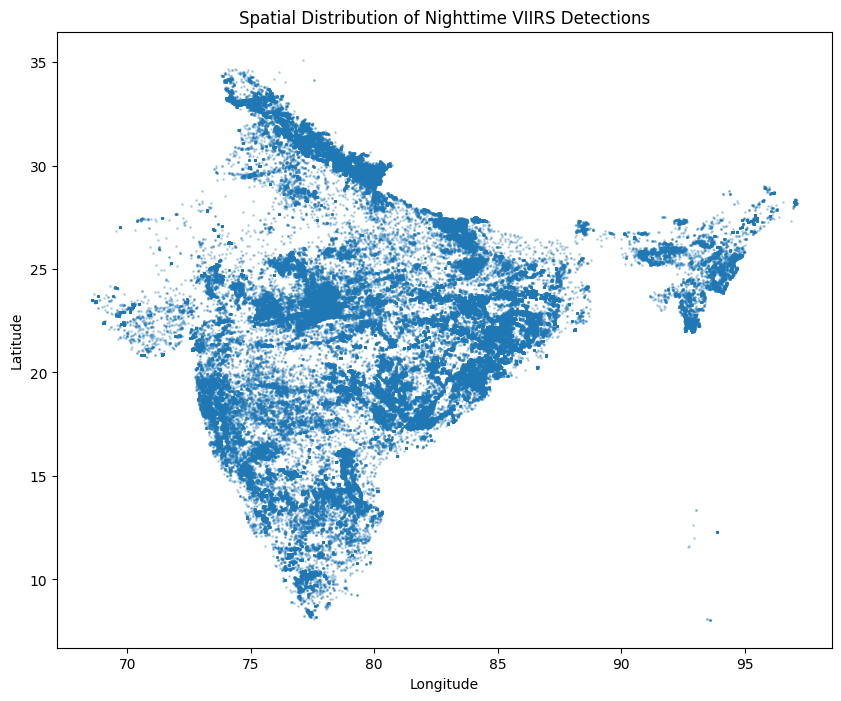

In [37]:
plt.figure(figsize=(10, 8))

plt.scatter(
    viirs_night["longitude"],
    viirs_night["latitude"],
    s=1,
    alpha=0.25
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Nighttime VIIRS Detections")

plt.show()

In [38]:
GRID_SIZE = 0.1

viirs_night["lat_grid"] = (
    np.floor(viirs_night["latitude"] / GRID_SIZE) * GRID_SIZE
)

viirs_night["lon_grid"] = (
    np.floor(viirs_night["longitude"] / GRID_SIZE) * GRID_SIZE
)

grid_counts = (
    viirs_night
    .groupby(["lat_grid", "lon_grid"])
    .size()
    .reset_index(name="detections")
)

display(
    grid_counts.sort_values(
        "detections",
        ascending=False
    ).head(20)
)

,lat_grid,lon_grid,detections
9777,23.700,86.300,11690
6169,20.900,85.100,7006
9778,23.700,86.400,5278
6274,21.100,72.600,3410
9631,23.600,87.100,3208
6032,20.700,85.200,3187
6530,21.300,81.600,2852
9776,23.700,86.200,2849
1838,15.100,76.600,2756
6177,20.900,86.000,2722


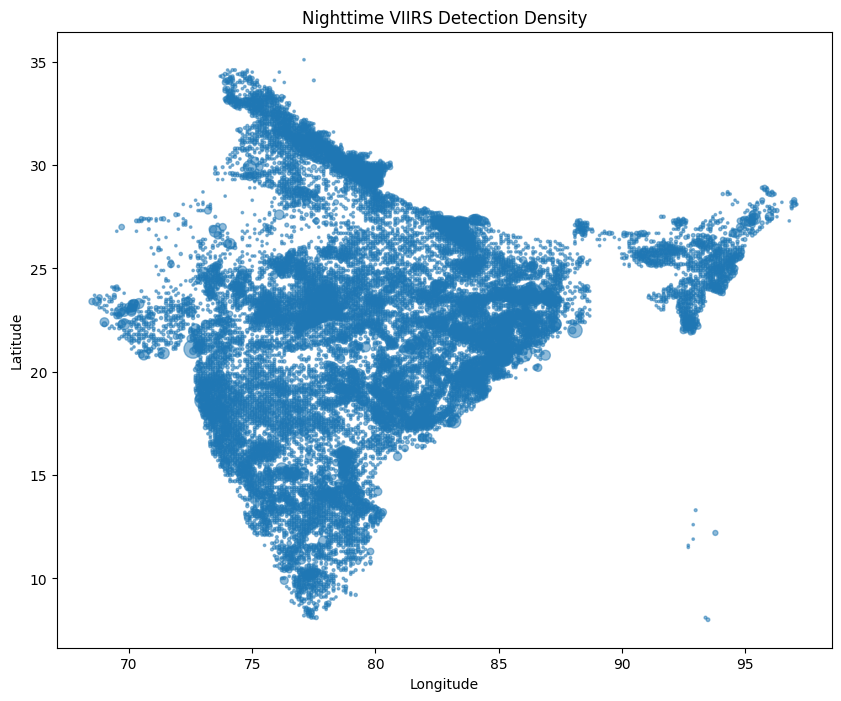

In [39]:
plt.figure(figsize=(10, 8))

plt.scatter(
    grid_counts["lon_grid"],
    grid_counts["lat_grid"],
    s=np.sqrt(grid_counts["detections"]) * 3,
    alpha=0.5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Nighttime VIIRS Detection Density")

plt.show()

In [40]:
viirs_night.to_csv(
    "viirs_night_2023_2024_eda.csv",
    index=False
)

print("Saved:", len(viirs_night), "nighttime detections")

Saved: 323659 nighttime detections
